# Advanced Matplotlib

This notebook is a focused study file for the **Matplotlib** Python library. It contains proper markdown notes and commented code examples for building, styling, arranging, annotating, and exporting plots.

## Learning Goals

- Understand the difference between the `pyplot` API and the object-oriented API.
- Create common chart types: line, bar, scatter, histogram, pie, box, heatmap, contour, and 3D plots.
- Customize titles, labels, legends, ticks, colors, grids, styles, and layouts.
- Build multi-panel dashboards and export publication-ready figures.

> Note: this notebook focuses on Matplotlib. Data is created with regular Python lists so the examples stay centered on the plotting library.

## 1. Import and Setup

The most common import is `matplotlib.pyplot as plt`.

`pyplot` is convenient for quick plots, while the object-oriented API gives better control for serious work.

In [1]:
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d import Axes3D  # Registers the 3D projection.

# Use a clean default style for the whole notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Global figure settings. These affect future plots unless changed.
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

import matplotlib
matplotlib.__version__

'3.10.8'

## 2. Basic Line Plot

A line plot is useful for showing change across ordered values such as time, epochs, or sorted measurements.

Important parts of a plot:

- `figure`: the whole drawing area.
- `axes`: the actual plotting area inside a figure.
- `axis`: the x-axis or y-axis scale and ticks.

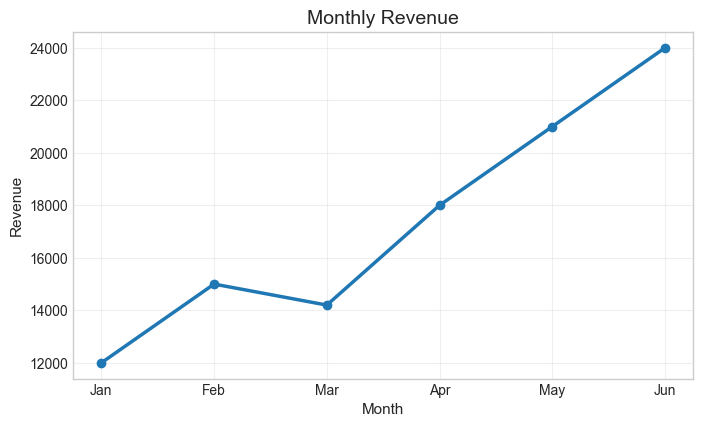

In [2]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
revenue = [12000, 15000, 14200, 18000, 21000, 24000]

fig, ax = plt.subplots() # means create a figure and a set of subplots (in this case, just one subplot). The variable `fig` refers to the entire figure, while `ax` refers to the specific axes (or subplot) where the data will be plotted.

# marker adds visible points; linewidth controls line thickness.
ax.plot(months, revenue, marker="o", linewidth=2.5, color="#1f77b4")

ax.set_title("Monthly Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.grid(True, alpha=0.3)

plt.show()

## 3. Figure and Axes: Object-Oriented API

For advanced plotting, prefer this pattern:

```python
fig, ax = plt.subplots()
ax.plot(...)
```

This makes it easier to manage multiple plots, customize axes, and save figures.

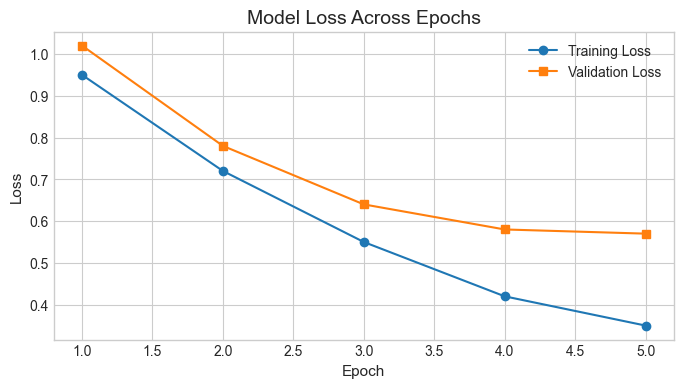

In [3]:
x = [1, 2, 3, 4, 5]
training_loss = [0.95, 0.72, 0.55, 0.42, 0.35]
validation_loss = [1.02, 0.78, 0.64, 0.58, 0.57]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, training_loss, label="Training Loss", marker="o")
ax.plot(x, validation_loss, label="Validation Loss", marker="s")

ax.set_title("Model Loss Across Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()   # Top-right corner by default

plt.show()

## 4. Styling Lines

Line plots can be customized with:

- `color`
- `linestyle`
- `linewidth`
- `marker`
- `markersize`
- `alpha` for transparency

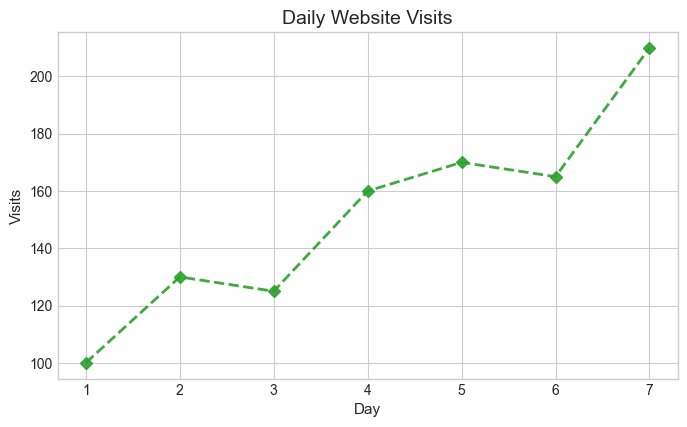

In [4]:
days = [1, 2, 3, 4, 5, 6, 7]
visits = [100, 130, 125, 160, 170, 165, 210]

fig, ax = plt.subplots()

ax.plot(
    days,
    visits,
    color="#2ca02c",
    linestyle="--",
    linewidth=2,
    marker="D",   # Diamond-shaped markers
    markersize=6,
    alpha=0.9     # Transparency of the line and markers
)

ax.set_title("Daily Website Visits")
ax.set_xlabel("Day")
ax.set_ylabel("Visits")

plt.show()

## 5. Multiple Lines and Legends

Use labels and `legend()` when multiple series appear on one plot.

A good legend helps the viewer decode the chart without guessing.

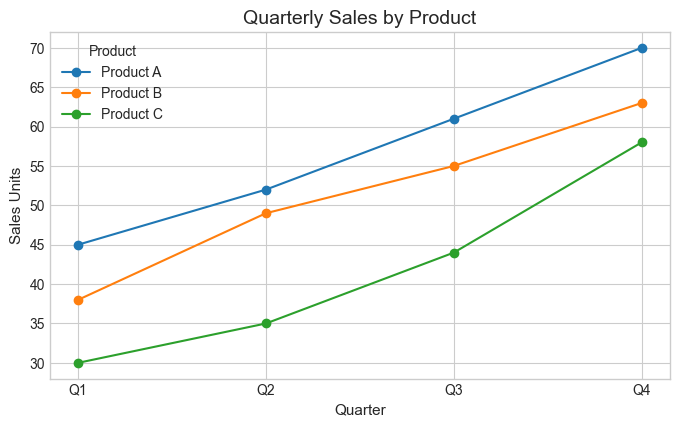

In [5]:
quarters = ["Q1", "Q2", "Q3", "Q4"]
product_a = [45, 52, 61, 70]
product_b = [38, 49, 55, 63]
product_c = [30, 35, 44, 58]

fig, ax = plt.subplots()

ax.plot(quarters, product_a, marker="o", label="Product A")
ax.plot(quarters, product_b, marker="o", label="Product B")
ax.plot(quarters, product_c, marker="o", label="Product C")

ax.set_title("Quarterly Sales by Product")
ax.set_xlabel("Quarter")
ax.set_ylabel("Sales Units")
ax.legend(title="Product")

plt.show()

## 6. Bar Chart

Bar charts compare categories. Keep category labels readable and sort values when ranking matters.

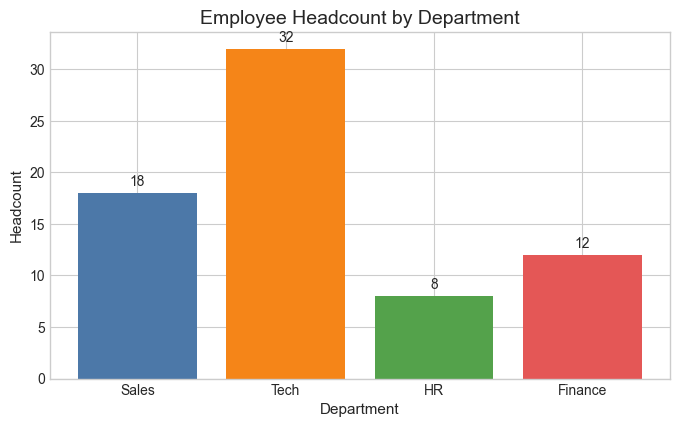

In [6]:
departments = ["Sales", "Tech", "HR", "Finance"]
headcount = [18, 32, 8, 12]

fig, ax = plt.subplots()

bars = ax.bar(departments, headcount, color=["#4c78a8", "#f58518", "#54a24b", "#e45756"])

ax.set_title("Employee Headcount by Department")
ax.set_xlabel("Department")
ax.set_ylabel("Headcount")

# Add value labels above bars.
ax.bar_label(bars, padding=3)

plt.show()

## 7. Horizontal Bar Chart

Horizontal bar charts are useful when category names are long.

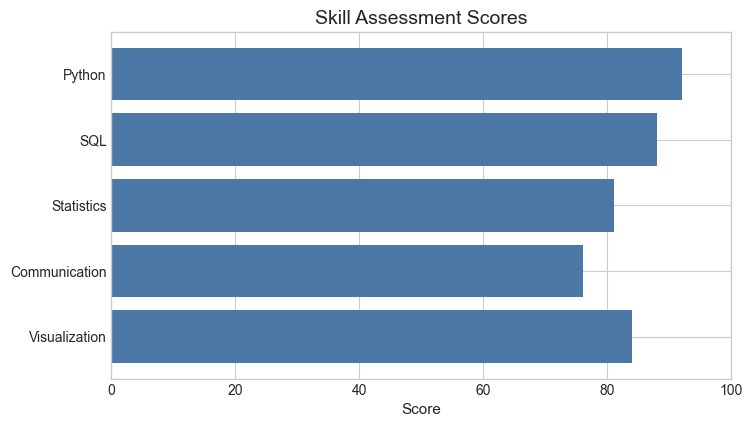

In [7]:
skills = ["Python", "SQL", "Statistics", "Communication", "Visualization"]
scores = [92, 88, 81, 76, 84]

fig, ax = plt.subplots()

ax.barh(skills, scores, color="#4c78a8")
ax.set_title("Skill Assessment Scores")
ax.set_xlabel("Score")
ax.set_xlim(0, 100)   # Set x-axis limits to 0-100 for better visualization.

# Put highest score at the top.
ax.invert_yaxis()

plt.show()

## 8. Grouped Bar Chart

Grouped bars compare multiple values inside each category.

The key idea is to offset bar positions manually.

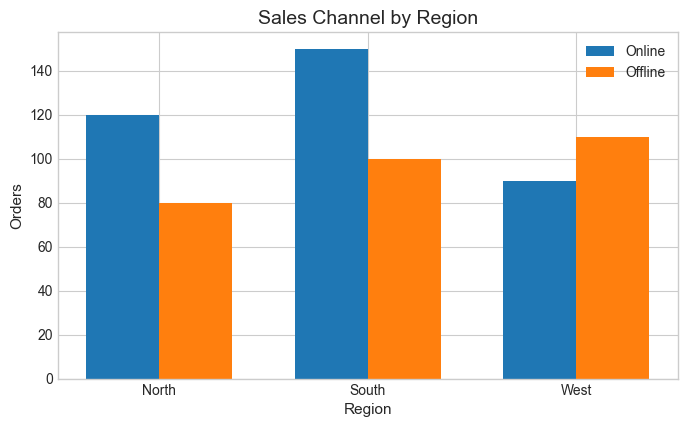

In [8]:
regions = ["North", "South", "West"]
online = [120, 150, 90]
offline = [80, 100, 110]
positions = [0, 1, 2]
width = 0.35

fig, ax = plt.subplots()

ax.bar([p - width / 2 for p in positions], online, width=width, label="Online") # means create a bar chart for online sales, with the bars centered at positions shifted left by half the width of the bars. The `label` parameter is used to specify the legend entry for this set of bars.
ax.bar([p + width / 2 for p in positions], offline, width=width, label="Offline") # means create a bar chart for offline sales, with the bars centered at positions shifted right by half the width of the bars. The `label` parameter is used to specify the legend entry for this set of bars.

ax.set_title("Sales Channel by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Orders")
ax.set_xticks(positions)
ax.set_xticklabels(regions)
ax.legend()

plt.show()

## 9. Pie Chart

Pie charts show part-to-whole relationships. Use them carefully; they work best with a small number of categories.

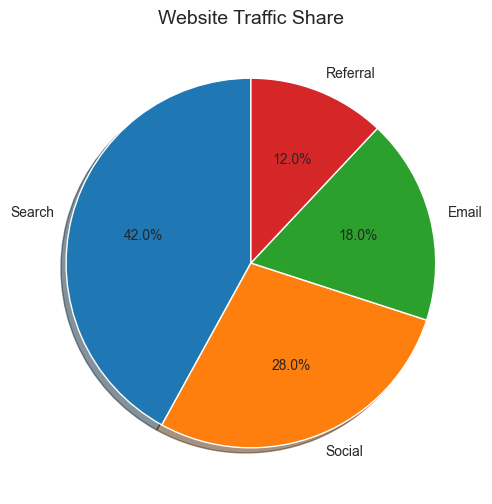

In [9]:
import matplotlib.pyplot as plt

channels = ["Search", "Social", "Email", "Referral"]
traffic_share = [42, 28, 18, 12]

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    traffic_share,
    labels=channels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"},
    shadow=True  # Adds the 3D shadow effect
)

ax.set_title("Website Traffic Share")

plt.show()


## 10. Scatter Plot

Scatter plots show relationships between two numeric variables.

Use color, size, and transparency to encode additional information.

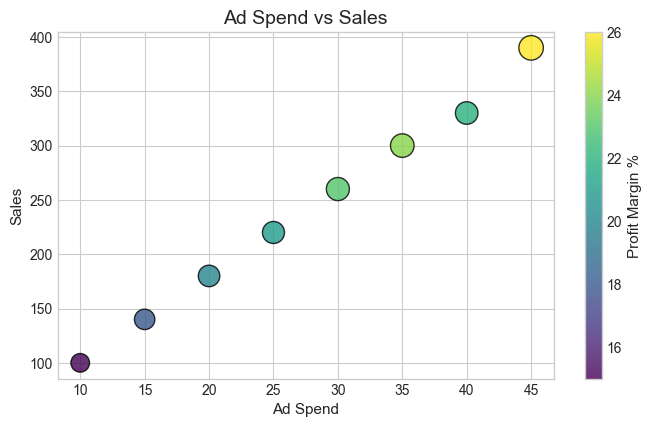

In [10]:
ad_spend = [10, 15, 20, 25, 30, 35, 40, 45]
sales = [100, 140, 180, 220, 260, 300, 330, 390]
profit_margin = [15, 18, 20, 21, 23, 24, 22, 26]

fig, ax = plt.subplots()

scatter = ax.scatter(
    ad_spend,
    sales,
    s=[m * 12 for m in profit_margin], # size of the points is proportional to profit margin
    c=profit_margin,
    cmap="viridis",
    alpha=0.8,
    edgecolor="black"
)

ax.set_title("Ad Spend vs Sales")
ax.set_xlabel("Ad Spend")
ax.set_ylabel("Sales")
fig.colorbar(scatter, ax=ax, label="Profit Margin %")

plt.show()

## 11. Histogram

Histograms show the distribution of one numeric variable.

`bins` controls how values are grouped.

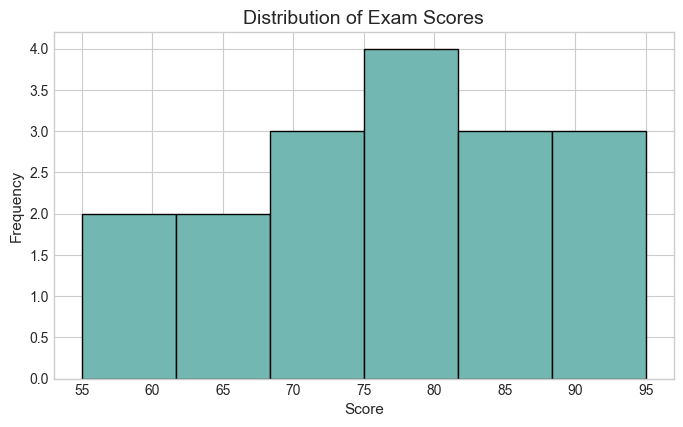

In [11]:
exam_scores = [55, 61, 62, 66, 70, 71, 72, 75, 78, 80, 81, 84, 85, 88, 90, 91, 95]

fig, ax = plt.subplots()

ax.hist(exam_scores, bins=6, color="#72b7b2", edgecolor="black")
ax.set_title("Distribution of Exam Scores")
ax.set_xlabel("Score")
ax.set_ylabel("Frequency")

plt.show()

## 12. Box Plot

Box plots summarize distributions with median, quartiles, and possible outliers.

They are useful for comparing spread across groups.

C:\Users\tarun\AppData\Local\Temp\ipykernel_13764\4020934878.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([team_a, team_b, team_c], labels=["Team A", "Team B", "Team C"], patch_artist=True)


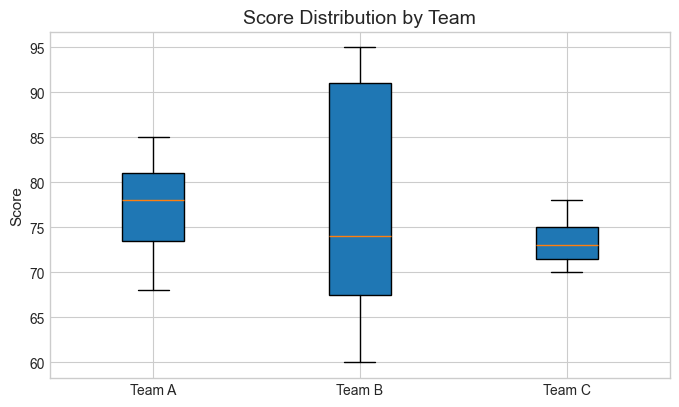

In [12]:
team_a = [68, 72, 75, 78, 80, 82, 85]
team_b = [60, 65, 70, 74, 90, 92, 95]
team_c = [70, 71, 72, 73, 74, 76, 78]

fig, ax = plt.subplots()

ax.boxplot([team_a, team_b, team_c], labels=["Team A", "Team B", "Team C"], patch_artist=True)
ax.set_title("Score Distribution by Team")
ax.set_ylabel("Score")

plt.show()

## 13. Subplots and Layouts

`plt.subplots(rows, columns)` creates multiple axes in one figure.

`constrained_layout=True` or `fig.tight_layout()` helps prevent overlapping labels.

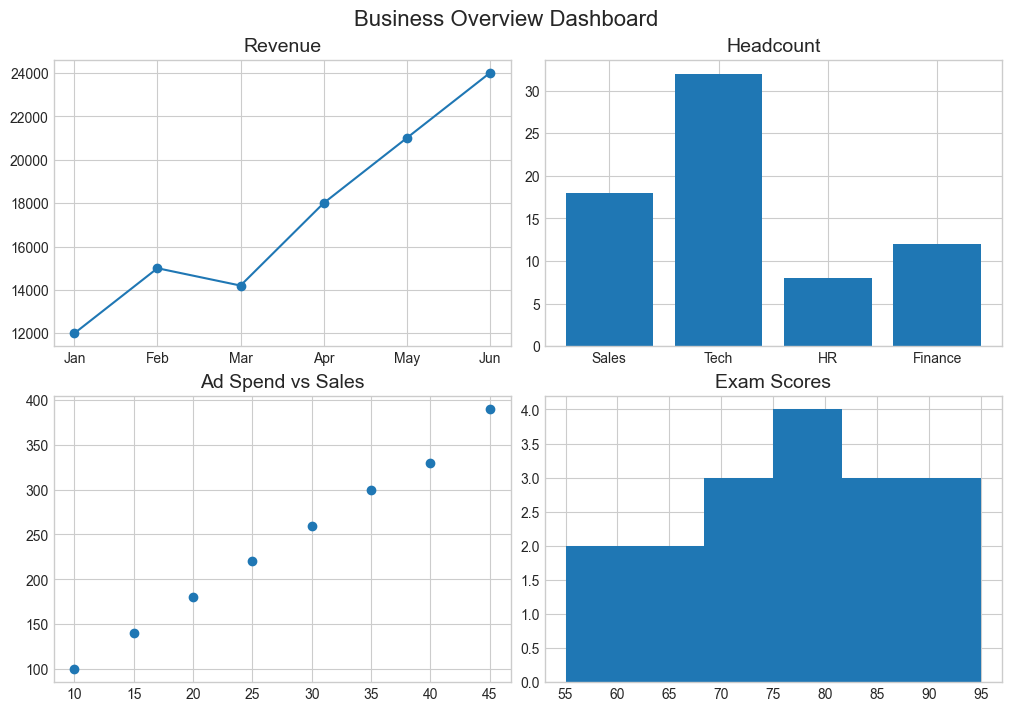

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

axes[0, 0].plot(months, revenue, marker="o")
axes[0, 0].set_title("Revenue")

axes[0, 1].bar(departments, headcount)
axes[0, 1].set_title("Headcount")

axes[1, 0].scatter(ad_spend, sales)
axes[1, 0].set_title("Ad Spend vs Sales")

axes[1, 1].hist(exam_scores, bins=6)
axes[1, 1].set_title("Exam Scores")

fig.suptitle("Business Overview Dashboard", fontsize=16)

plt.show()

## 14. Figure Size and DPI

`figsize=(width, height)` controls size in inches.

`dpi` controls pixels per inch. Higher DPI is useful for exported images.

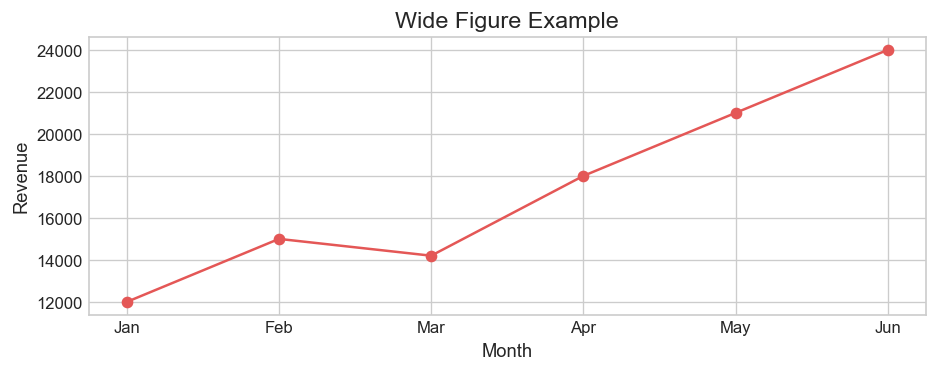

In [16]:
fig, ax = plt.subplots(figsize=(9, 3), dpi=120)

ax.plot(months, revenue, marker="o", color="#e45756")
ax.set_title("Wide Figure Example")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")

plt.show()

## 15. Annotations and Text

Annotations call attention to important values, events, or unusual points.

`annotate()` can draw text and an arrow pointing to a location.

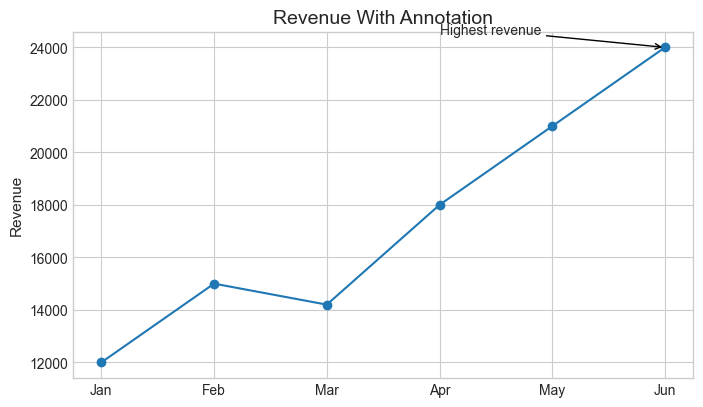

In [17]:
fig, ax = plt.subplots()

ax.plot(months, revenue, marker="o")
ax.set_title("Revenue With Annotation")
ax.set_ylabel("Revenue")

# Highlight the highest revenue month.
ax.annotate(
    "Highest revenue",
    xy=("Jun", 24000),
    xytext=("Apr", 24500),
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=10
)

plt.show()

## 16. Axis Customization

Axis customization improves readability.

Useful methods:

- `set_xlim()` and `set_ylim()`
- `set_xticks()` and `set_yticks()`
- `tick_params()`
- `spines` customization
- `ticker` formatters

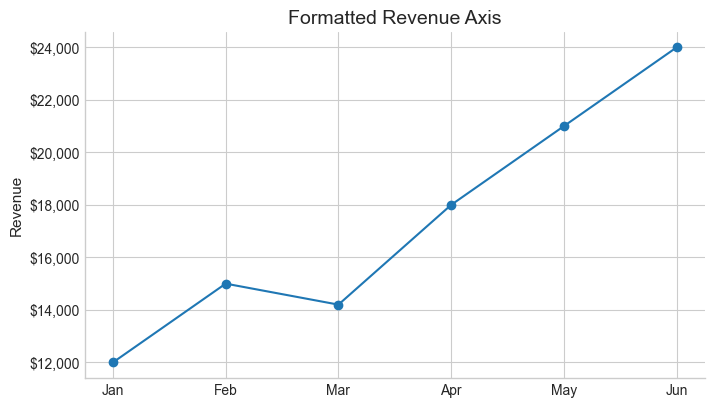

In [18]:
fig, ax = plt.subplots()

ax.plot(months, revenue, marker="o")
ax.set_title("Formatted Revenue Axis")
ax.set_ylabel("Revenue")

# Format y-axis values with a currency symbol.
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))

# Hide unnecessary borders for a cleaner chart.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", rotation=0)

plt.show()

## 17. Twin Axes

Twin axes show two measures with different units on the same x-axis.

Use this carefully because it can be misleading if scales are not clearly labeled.

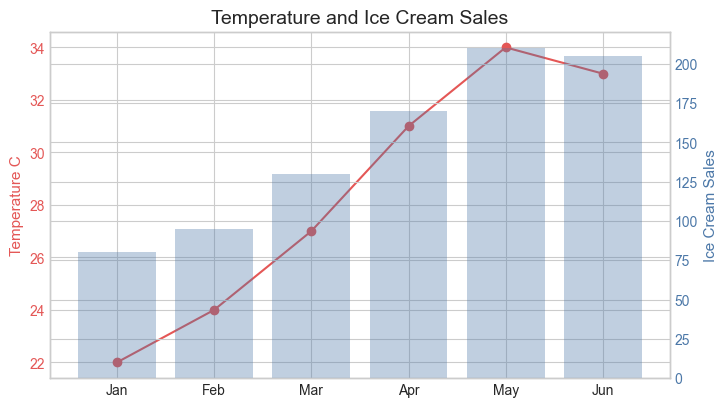

In [19]:
temperature = [22, 24, 27, 31, 34, 33]
ice_cream_sales = [80, 95, 130, 170, 210, 205]

fig, ax1 = plt.subplots()

ax1.plot(months, temperature, color="#e45756", marker="o", label="Temperature")
ax1.set_ylabel("Temperature C", color="#e45756")
ax1.tick_params(axis="y", labelcolor="#e45756")

# Create a second y-axis that shares the same x-axis.
ax2 = ax1.twinx()
ax2.bar(months, ice_cream_sales, color="#4c78a8", alpha=0.35, label="Sales")
ax2.set_ylabel("Ice Cream Sales", color="#4c78a8")
ax2.tick_params(axis="y", labelcolor="#4c78a8")

ax1.set_title("Temperature and Ice Cream Sales")

plt.show()

## 18. Logarithmic Scale

Use a log scale when values span several orders of magnitude.

A log scale can make exponential growth or highly skewed data easier to read.

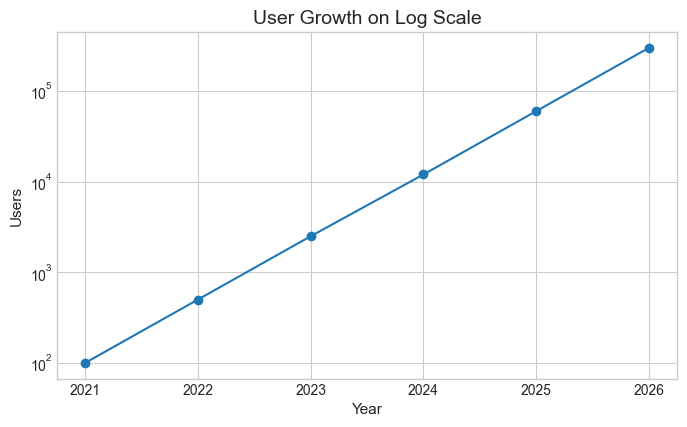

In [20]:
years = [2021, 2022, 2023, 2024, 2025, 2026]
users = [100, 500, 2500, 12000, 60000, 300000]

fig, ax = plt.subplots()

ax.plot(years, users, marker="o")
ax.set_yscale("log")
ax.set_title("User Growth on Log Scale")
ax.set_xlabel("Year")
ax.set_ylabel("Users")

plt.show()

## 19. Fill Between

`fill_between()` shades the area between a line and a baseline or between two lines.

It is useful for ranges, uncertainty bands, and positive/negative areas.

In [ ]:
week = [1, 2, 3, 4, 5, 6, 7]
actual = [100, 115, 112, 130, 145, 150, 165]
target = [105, 110, 120, 125, 135, 145, 155]

fig, ax = plt.subplots()

ax.plot(week, actual, label="Actual", marker="o")
ax.plot(week, target, label="Target", marker="s")
ax.fill_between(week, actual, target, where=[a >= t for a, t in zip(actual, target)], alpha=0.25, color="green")
ax.fill_between(week, actual, target, where=[a < t for a, t in zip(actual, target)], alpha=0.25, color="red")

ax.set_title("Actual vs Target")
ax.set_xlabel("Week")
ax.legend()

plt.show()

## 20. Stack Plot

Stack plots show how multiple parts contribute to a total over an ordered axis.

In [ ]:
days = [1, 2, 3, 4, 5]
search = [50, 60, 70, 65, 80]
social = [30, 35, 45, 50, 55]
email = [20, 25, 28, 30, 35]

fig, ax = plt.subplots()

ax.stackplot(days, search, social, email, labels=["Search", "Social", "Email"], alpha=0.8)
ax.set_title("Traffic Sources Over Time")
ax.set_xlabel("Day")
ax.set_ylabel("Visits")
ax.legend(loc="upper left")

plt.show()

## 21. Heatmap with imshow

`imshow()` displays a 2D grid of values as colors.

Heatmaps are useful for matrices, correlation-like tables, calendar patterns, and intensity maps.

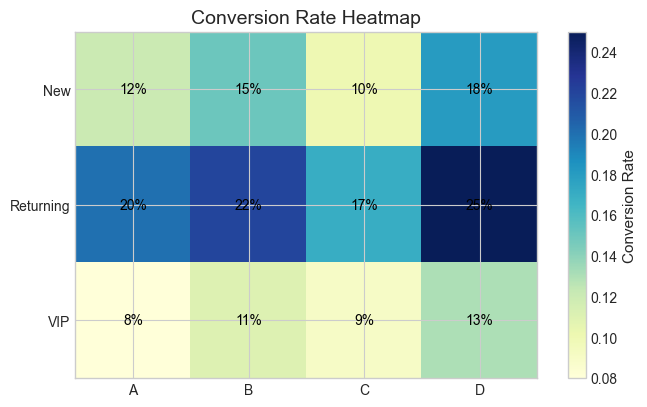

In [4]:
conversion_matrix = [
    [0.12, 0.15, 0.10, 0.18],
    [0.20, 0.22, 0.17, 0.25],
    [0.08, 0.11, 0.09, 0.13]
]
segments = ["New", "Returning", "VIP"]
campaigns = ["A", "B", "C", "D"]

fig, ax = plt.subplots()

image = ax.imshow(conversion_matrix, cmap="YlGnBu")
ax.set_title("Conversion Rate Heatmap")
ax.set_xticks(range(len(campaigns)))
ax.set_xticklabels(campaigns)
ax.set_yticks(range(len(segments)))
ax.set_yticklabels(segments)

# Add each value inside the heatmap cell.
for row_index, row in enumerate(conversion_matrix):
    for col_index, value in enumerate(row):
        ax.text(col_index, row_index, f"{value:.0%}", ha="center", va="center", color="black")

fig.colorbar(image, ax=ax, label="Conversion Rate")

plt.show()

## 22. Contour Plot

Contour plots show levels of a third value across two dimensions.

Here, `x_grid`, `y_grid`, and `z_grid` are plain Python nested lists.

In [ ]:
x_values = [-2, -1, 0, 1, 2]
y_values = [-2, -1, 0, 1, 2]

# Create grid data manually without using extra libraries.
x_grid = [[x for x in x_values] for _ in y_values]
y_grid = [[y for _ in x_values] for y in y_values]
z_grid = [[x**2 + y**2 for x in x_values] for y in y_values]

fig, ax = plt.subplots()

contours = ax.contour(x_grid, y_grid, z_grid, levels=6, colors="black")
filled = ax.contourf(x_grid, y_grid, z_grid, levels=6, cmap="viridis", alpha=0.75)
ax.clabel(contours, inline=True, fontsize=8)

ax.set_title("Contour Plot Example")
ax.set_xlabel("X")
ax.set_ylabel("Y")
fig.colorbar(filled, ax=ax)

plt.show()

## 23. 3D Plot

Matplotlib supports 3D plots through the `mplot3d` toolkit.

Use 3D charts only when they add clarity; many comparisons are easier in 2D.

In [ ]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")

x_points = [1, 2, 3, 4, 5]
y_points = [2, 3, 5, 7, 11]
z_points = [1, 4, 9, 16, 25]

ax.scatter(x_points, y_points, z_points, s=80, c=z_points, cmap="plasma")
ax.set_title("3D Scatter Plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

## 24. Styles and Themes

Matplotlib includes built-in styles. A style changes colors, grids, backgrounds, and other visual defaults.

Useful commands:

```python
plt.style.available
plt.style.use("ggplot")
```

In [ ]:
# Use a temporary style context for only this plot.
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.plot(months, revenue, marker="o")
    ax.set_title("Temporary ggplot Style")
    ax.set_ylabel("Revenue")
    plt.show()

## 25. Saving Figures

`savefig()` exports figures.

Common formats:

- PNG for general use.
- JPG for compressed images.
- SVG for vector graphics.
- PDF for reports and printing.

Important options:

- `dpi`: output resolution.
- `bbox_inches="tight"`: trims extra whitespace.
- `transparent=True`: transparent background.

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, revenue, marker="o")
ax.set_title("Figure Ready for Export")
ax.set_ylabel("Revenue")

# Uncomment this line when you want to save the figure.
# fig.savefig("monthly_revenue.png", dpi=300, bbox_inches="tight")

plt.show()

## 26. Real-World Mini Project: Sales Dashboard

This section combines several Matplotlib skills into one compact dashboard:

- A line chart for revenue trend.
- A bar chart for regional revenue.
- A scatter plot for spend vs revenue.
- A pie chart for channel share.

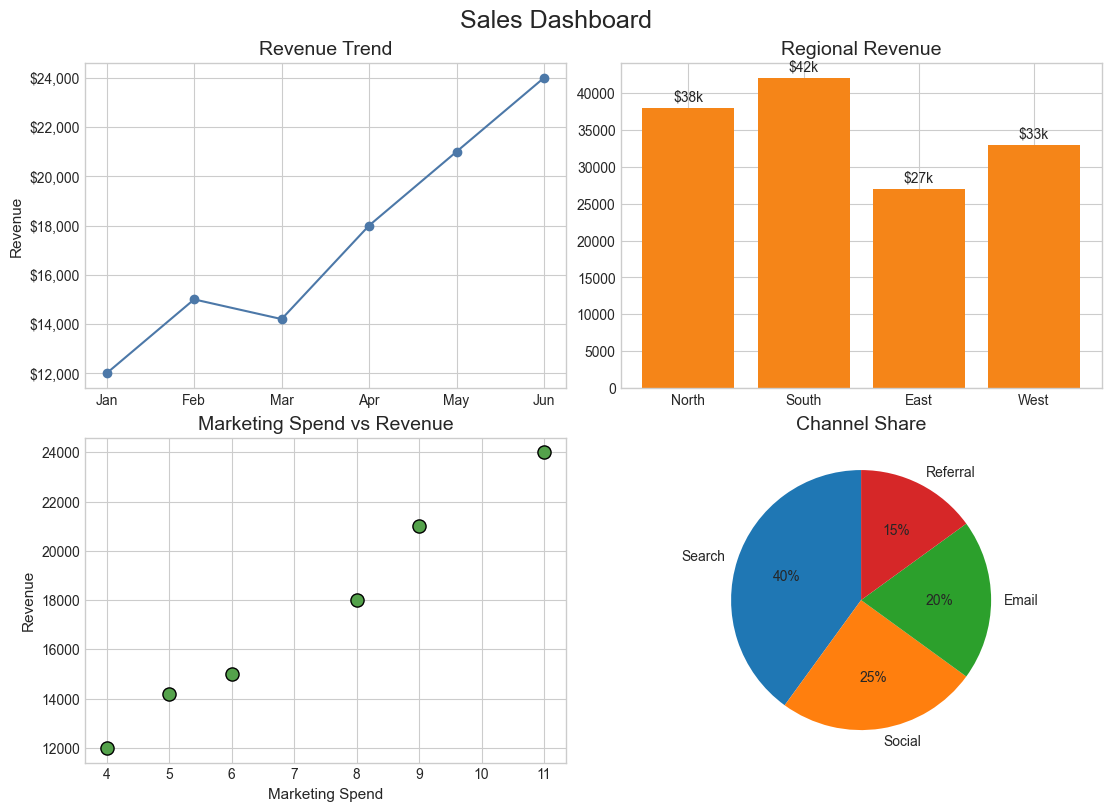

In [5]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
revenue = [12000, 15000, 14200, 18000, 21000, 24000]
regions = ["North", "South", "East", "West"]
regional_revenue = [38000, 42000, 27000, 33000]
marketing_spend = [4, 6, 5, 8, 9, 11]
channel_labels = ["Search", "Social", "Email", "Referral"]
channel_share = [40, 25, 20, 15]

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

# 1. Revenue trend.
axes[0, 0].plot(months, revenue, marker="o", color="#4c78a8")
axes[0, 0].set_title("Revenue Trend")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))

# 2. Regional revenue.
bars = axes[0, 1].bar(regions, regional_revenue, color="#f58518")
axes[0, 1].set_title("Regional Revenue")
axes[0, 1].bar_label(bars, labels=[f"${v/1000:.0f}k" for v in regional_revenue], padding=3)

# 3. Spend vs revenue.
axes[1, 0].scatter(marketing_spend, revenue, s=90, color="#54a24b", edgecolor="black")
axes[1, 0].set_title("Marketing Spend vs Revenue")
axes[1, 0].set_xlabel("Marketing Spend")
axes[1, 0].set_ylabel("Revenue")

# 4. Channel share.
axes[1, 1].pie(channel_share, labels=channel_labels, autopct="%1.0f%%", startangle=90)
axes[1, 1].set_title("Channel Share")

fig.suptitle("Sales Dashboard", fontsize=18)

plt.show()

## 27. Quick Revision Checklist

- Use `fig, ax = plt.subplots()` for clear, controllable plots.
- Add `title`, `xlabel`, `ylabel`, and `legend` when needed.
- Use color, marker, linestyle, alpha, and linewidth to improve readability.
- Use bar charts for categories and line charts for ordered trends.
- Use scatter plots for relationships and histograms for distributions.
- Use `subplots()` for dashboards and comparisons.
- Use `annotate()` for key points.
- Format axes with `ticker` when values need currency, percent, or commas.
- Use styles carefully; clarity matters more than decoration.
- Use `savefig()` with `dpi=300` and `bbox_inches="tight"` for export-quality figures.